# 🦜🔗 LangGraph — In-Depth Revision Notebook
### *Production-Grade | Interview-Ready | Portfolio-Worthy*

---

```
Author     : Rakesh Kumar (SDE2 @ CGI | Masters AI/ML)
Purpose    : Deep revision of LangGraph for ML/GenAI interviews & production projects
Stack      : LangGraph + LangChain + OpenAI + SQLite checkpointing
```

---

## 📋 Table of Contents

| # | Topic | Production Relevance |
|---|-------|---------------------|
| 1 | What is LangGraph & Why it matters | Core Foundation |
| 2 | Installation & Setup | Dev Environment |
| 3 | Core Concepts: State, Nodes, Edges | Architecture |
| 4 | Minimal Graph — Hello World | Basics |
| 5 | State Management & Reducers | Production Critical |
| 6 | Conditional Routing | Control Flow |
| 7 | Cyclic Workflows (Agent Loops) | ReAct Agents |
| 8 | Tool Calling Agents | Real Agents |
| 9 | Memory & Checkpointing | Stateful Apps |
| 10 | Persistence with SQLite | Production DB |
| 11 | Streaming (Sync & Async) | Real-time Apps |
| 12 | Human-in-the-Loop | Approval Workflows |
| 13 | Multi-Agent Systems | Complex Systems |
| 14 | Parallel Execution | Performance |
| 15 | Subgraphs (Reusable Modules) | Modularity |
| 16 | ReAct Style Agent — Full Build | Interview Favorite |
| 17 | Simple RAG Workflow | NLP Project |
| 18 | Error Handling & Retry | Reliability |
| 19 | Graph Visualization | Debugging |
| 20 | 🔥 Industry Questions + Interview Q&A | Must Revise |


---
## 1. 🧠 What is LangGraph & Why It Matters

### Theory
LangGraph is a **stateful, graph-based orchestration framework** built on top of LangChain. It allows you to build:
- **Cyclic workflows** (unlike LangChain's linear chains)
- **Multi-agent systems** where agents collaborate
- **Stateful applications** that remember context across steps
- **Human-in-the-loop** pipelines with pause/resume

### Why LangGraph over plain LangChain?

| Feature | LangChain | LangGraph |
|---------|-----------|----------|
| Flow type | Linear (DAG only) | Cyclic + DAG |
| State management | Limited | First-class citizen |
| Agent loops | Hacky workarounds | Native support |
| Human approval | Not built-in | `interrupt()` built-in |
| Multi-agent | Manual | Native nodes |
| Checkpointing | No | Yes (SQLite, Redis) |

### Industry Use Cases
```
✅ AI Assistants (ChatBots with memory)
✅ RAG Pipelines with routing
✅ Autonomous Research Agents
✅ Multi-Agent Collaboration (Planner → Writer → Reviewer)
✅ Customer Support Automation
✅ Data Analysis Agents
✅ Code Generation + Review Pipelines
```

> 💡 **Interview Tip**: Always mention LangGraph when asked about *stateful agents* or *multi-agent systems*. It shows production awareness.


---
## 2. ⚙️ Installation & Setup


In [ ]:
# Install all required packages
!pip install langgraph langchain langchain-openai langchain-community
!pip install python-dotenv  # for API key management
!pip install tenacity       # for retry logic
!pip install asyncio        # async support (usually pre-installed)

In [ ]:
import os
from dotenv import load_dotenv

load_dotenv()  # loads from .env file

# OR set directly (not recommended for production)
# os.environ["OPENAI_API_KEY"] = "your-key-here"

# Verify key is set
print("API Key loaded:", bool(os.getenv("OPENAI_API_KEY")))

---
## 3. 🧩 Core Concepts: State, Nodes, Edges

### The 6 Building Blocks

```
┌─────────────────────────────────────────────────────────┐
│                   LANGGRAPH ANATOMY                     │
│                                                         │
│  STATE      = Shared memory (TypedDict)                 │
│  NODE       = A function (agent, tool, step)            │
│  EDGE       = Connection between nodes                  │
│  START      = Entry point of the graph                  │
│  END        = Exit point of the graph                   │
│  COND EDGE  = Dynamic routing based on state            │
│  REDUCER    = Merges state updates from multiple nodes  │
└─────────────────────────────────────────────────────────┘
```

### State — The Heart of LangGraph
State is a **TypedDict** that flows through all nodes. Each node **reads** the current state and **returns partial updates**. LangGraph **merges** them automatically.

```python
# Simple State
class State(TypedDict):
    messages: list
    user_name: str
    score: int
```

### Reducer — For Complex State Updates
By default, LangGraph **overwrites** fields. For lists (like message history), you want to **append**, not overwrite. Use Annotated + reducer:

```python
from typing import Annotated
from operator import add

class State(TypedDict):
    messages: Annotated[list, add]   # append new messages
    score: int                        # overwrite
```

> 🔥 **Interview Tip**: "What is a Reducer in LangGraph?" — This is a common question. Reducers prevent race conditions when multiple nodes update the same state field.


---
## 4. 🌱 Minimal Graph — Hello World


In [ ]:
from typing import TypedDict
from langgraph.graph import StateGraph, END

# ── Step 1: Define State ──────────────────────────────
class State(TypedDict):
    message: str

# ── Step 2: Define Nodes (functions) ─────────────────
def hello_node(state: State) -> dict:
    """Node that processes the message"""
    return {"message": f"Hello, {state['message']}!"}

def shout_node(state: State) -> dict:
    """Node that uppercases the message"""
    return {"message": state["message"].upper()}

# ── Step 3: Build Graph ───────────────────────────────
workflow = StateGraph(State)

workflow.add_node("hello", hello_node)
workflow.add_node("shout", shout_node)

# ── Step 4: Add Edges ─────────────────────────────────
workflow.set_entry_point("hello")    # START → hello
workflow.add_edge("hello", "shout")  # hello → shout
workflow.add_edge("shout", END)      # shout → END

# ── Step 5: Compile & Run ─────────────────────────────
app = workflow.compile()

result = app.invoke({"message": "Rakesh"})
print(result)  # {'message': 'HELLO, RAKESH!'}

In [ ]:
# Visualize the graph (production debugging trick)
try:
    from IPython.display import Image, display
    display(Image(app.get_graph().draw_mermaid_png()))
except Exception as e:
    print("Install graphviz for visualization:", e)
    print(app.get_graph().draw_mermaid())  # fallback: mermaid text

---
## 5. 🗃️ State Management & Reducers (Production Critical)


In [ ]:
from typing import TypedDict, Annotated, List
from operator import add
from langgraph.graph import StateGraph, END

# ── Production State with Reducers ───────────────────
class AgentState(TypedDict):
    # Annotated[list, add] means: append new items instead of overwrite
    messages: Annotated[List[str], add]
    step_count: int       # simple overwrite
    final_answer: str     # simple overwrite

# ── Nodes ─────────────────────────────────────────────
def step_one(state: AgentState) -> dict:
    return {
        "messages": ["Step 1: Received input"],  # APPENDS
        "step_count": state["step_count"] + 1
    }

def step_two(state: AgentState) -> dict:
    return {
        "messages": ["Step 2: Processing data"],  # APPENDS
        "step_count": state["step_count"] + 1
    }

def step_three(state: AgentState) -> dict:
    return {
        "messages": ["Step 3: Done!"],
        "step_count": state["step_count"] + 1,
        "final_answer": "All steps completed successfully"
    }

# ── Build & Run ───────────────────────────────────────
workflow = StateGraph(AgentState)
workflow.add_node("step_one", step_one)
workflow.add_node("step_two", step_two)
workflow.add_node("step_three", step_three)

workflow.set_entry_point("step_one")
workflow.add_edge("step_one", "step_two")
workflow.add_edge("step_two", "step_three")
workflow.add_edge("step_three", END)

app = workflow.compile()
result = app.invoke({"messages": [], "step_count": 0, "final_answer": ""})

print("Messages accumulated:", result["messages"])
print("Total steps:", result["step_count"])
print("Final answer:", result["final_answer"])

---
## 6. 🔀 Conditional Routing

### Why it matters
Real agents don't follow fixed paths. They decide **which node to go to next** based on current state. Conditional edges = dynamic routing.

```
         ┌──── pass ────► success_node
check ───┤
         └──── fail ────► retry_node
```


In [ ]:
from typing import TypedDict, Literal
from langgraph.graph import StateGraph, END

class State(TypedDict):
    score: int
    result: str
    attempts: int

# ── Router Function ───────────────────────────────────
def router(state: State) -> Literal["pass", "fail"]:
    """Returns next node name based on state"""
    if state["score"] >= 50:
        return "pass"
    else:
        return "fail"

# ── Nodes ─────────────────────────────────────────────
def check_node(state: State) -> dict:
    print(f"Checking score: {state['score']}")
    return {}  # no state change, just routing

def success_node(state: State) -> dict:
    return {"result": f"✅ Passed with score {state['score']}"}

def retry_node(state: State) -> dict:
    new_score = state["score"] + 20  # simulate improvement
    return {
        "score": new_score,
        "attempts": state["attempts"] + 1,
        "result": f"🔁 Retry #{state['attempts']+1} — new score: {new_score}"
    }

# ── Build Graph ───────────────────────────────────────
workflow = StateGraph(State)
workflow.add_node("check", check_node)
workflow.add_node("success", success_node)
workflow.add_node("retry", retry_node)

workflow.set_entry_point("check")

# add_conditional_edges(from_node, router_fn, mapping)
workflow.add_conditional_edges(
    "check",
    router,
    {
        "pass": "success",
        "fail": "retry"
    }
)
workflow.add_edge("retry", "check")   # retry loops back to check!
workflow.add_edge("success", END)

app = workflow.compile()

# Test with failing score first
result = app.invoke({"score": 30, "result": "", "attempts": 0})
print(result)

---
## 7. 🔄 Cyclic Workflows — Agent Loops

### Theory
This is LangGraph's killer feature. Unlike DAGs, **cyclic graphs let agents loop** until a condition is met — exactly how ReAct agents work:

```
Agent ──► Tool ──► Agent ──► Tool ──► ... ──► END
  ▲___________________|  (loop until done)
```

> 🔥 **Interview Tip**: "Why LangGraph over AutoGen or CrewAI?" — LangGraph gives **fine-grained control** over state, routing, and checkpointing, making it more production-ready.


In [ ]:
from typing import TypedDict, Annotated, Literal
from operator import add
from langgraph.graph import StateGraph, END

class AgentState(TypedDict):
    task: str
    history: Annotated[list, add]
    iteration: int
    done: bool

# ── Simulated Agent & Tool ────────────────────────────
def agent_node(state: AgentState) -> dict:
    """Agent decides what to do next"""
    iteration = state["iteration"]
    if iteration >= 3:  # stop condition
        return {
            "history": [f"Agent: Task complete after {iteration} iterations"],
            "done": True
        }
    return {
        "history": [f"Agent: Iteration {iteration+1} — calling tool"],
        "done": False
    }

def tool_node(state: AgentState) -> dict:
    """Tool executes and returns result"""
    return {
        "history": [f"Tool: Executed at iteration {state['iteration']+1}"],
        "iteration": state["iteration"] + 1
    }

# ── Router for the cycle ──────────────────────────────
def should_continue(state: AgentState) -> Literal["tool", "end"]:
    return "end" if state["done"] else "tool"

# ── Build Cyclic Graph ────────────────────────────────
workflow = StateGraph(AgentState)
workflow.add_node("agent", agent_node)
workflow.add_node("tool", tool_node)

workflow.set_entry_point("agent")
workflow.add_conditional_edges("agent", should_continue, {"tool": "tool", "end": END})
workflow.add_edge("tool", "agent")  # ← This creates the CYCLE

app = workflow.compile()

result = app.invoke({"task": "Analyze data", "history": [], "iteration": 0, "done": False})

print("Execution History:")
for step in result["history"]:
    print(" ", step)

---
## 8. 🛠️ Tool Calling Agents (Real Production Agents)

### Theory
Real agents need to call **external tools** — search APIs, calculators, databases, code executors. LangGraph integrates natively with LangChain tools via `@tool` decorator.


In [ ]:
from typing import TypedDict, Annotated
from operator import add
from langchain_core.tools import tool
from langchain_openai import ChatOpenAI
from langchain_core.messages import HumanMessage, AIMessage, ToolMessage
from langgraph.graph import StateGraph, END
import json

# ── Define Tools ──────────────────────────────────────
@tool
def search_tool(query: str) -> str:
    """Search the web for information."""
    # In production: integrate with Tavily, SerpAPI, etc.
    return f"Search results for '{query}': [Simulated result about {query}]"

@tool
def calculator_tool(expression: str) -> str:
    """Evaluate a mathematical expression."""
    try:
        result = eval(expression)  # use safer eval in production
        return str(result)
    except Exception as e:
        return f"Error: {e}"

tools = [search_tool, calculator_tool]
tools_by_name = {t.name: t for t in tools}

# ── State ─────────────────────────────────────────────
class AgentState(TypedDict):
    messages: Annotated[list, add]

# ── LLM with tool binding ─────────────────────────────
llm = ChatOpenAI(model="gpt-4o-mini", temperature=0)
llm_with_tools = llm.bind_tools(tools)

# ── Agent Node ────────────────────────────────────────
def agent_node(state: AgentState) -> dict:
    """LLM decides whether to call a tool or finish"""
    response = llm_with_tools.invoke(state["messages"])
    return {"messages": [response]}

# ── Tool Executor Node ────────────────────────────────
def tool_node(state: AgentState) -> dict:
    """Execute all tool calls from the last agent message"""
    last_message = state["messages"][-1]
    tool_results = []
    
    for tool_call in last_message.tool_calls:
        tool_fn = tools_by_name[tool_call["name"]]
        result = tool_fn.invoke(tool_call["args"])
        tool_results.append(
            ToolMessage(content=result, tool_call_id=tool_call["id"])
        )
    
    return {"messages": tool_results}

# ── Router ────────────────────────────────────────────
def should_use_tool(state: AgentState):
    last_message = state["messages"][-1]
    if hasattr(last_message, "tool_calls") and last_message.tool_calls:
        return "tools"
    return "end"

# ── Build Graph ───────────────────────────────────────
workflow = StateGraph(AgentState)
workflow.add_node("agent", agent_node)
workflow.add_node("tools", tool_node)

workflow.set_entry_point("agent")
workflow.add_conditional_edges("agent", should_use_tool, {"tools": "tools", "end": END})
workflow.add_edge("tools", "agent")  # tool result → back to agent

app = workflow.compile()

# ── Run ───────────────────────────────────────────────
# result = app.invoke({
#     "messages": [HumanMessage(content="What is 25 * 4 + 100?")]
# })
# print(result["messages"][-1].content)

print("✅ Tool Calling Agent Graph compiled successfully!")
print("Nodes:", list(app.get_graph().nodes.keys()))

---
## 9. 💾 Memory & Checkpointing

### Theory
Without checkpointing, every `app.invoke()` starts fresh. With checkpointing:
- State is **saved after every step**
- Can **resume** interrupted workflows
- Enables **multi-turn conversations** with memory
- Essential for **Human-in-the-Loop** flows

### Checkpointer Types
| Type | Use Case |
|------|----------|
| `MemorySaver` | Dev/testing — in-memory |
| `SqliteSaver` | Production single-server |
| `PostgresSaver` | Production distributed |
| `RedisSaver` | High-throughput production |

> 🔥 **Interview Tip**: "How do you maintain conversation history across sessions?" — Answer with checkpointing + `thread_id`.


In [ ]:
from typing import TypedDict, Annotated
from operator import add
from langgraph.graph import StateGraph, END
from langgraph.checkpoint.memory import MemorySaver

class ConversationState(TypedDict):
    messages: Annotated[list, add]
    turn_count: int

def respond(state: ConversationState) -> dict:
    last_msg = state["messages"][-1]
    response = f"Echo [{state['turn_count']+1}]: {last_msg}"
    return {
        "messages": [response],
        "turn_count": state["turn_count"] + 1
    }

# ── Build with MemorySaver ────────────────────────────
workflow = StateGraph(ConversationState)
workflow.add_node("respond", respond)
workflow.set_entry_point("respond")
workflow.add_edge("respond", END)

memory = MemorySaver()
app = workflow.compile(checkpointer=memory)

# ── Thread ID = conversation session ─────────────────
config = {"configurable": {"thread_id": "user_rakesh_session_1"}}

# Turn 1
r1 = app.invoke({"messages": ["Hello!"], "turn_count": 0}, config)
print("Turn 1:", r1["messages"])

# Turn 2 — continues from saved state
r2 = app.invoke({"messages": ["How are you?"]}, config)  # no need to re-init
print("Turn 2:", r2["messages"])

# Check saved state
saved_state = app.get_state(config)
print("\nTotal turns:", saved_state.values["turn_count"])
print("All messages:", saved_state.values["messages"])

---
## 10. 🗄️ Persistence with SQLite (Production Setup)


In [ ]:
from langgraph.checkpoint.sqlite import SqliteSaver
from typing import TypedDict, Annotated
from operator import add
from langgraph.graph import StateGraph, END

class State(TypedDict):
    messages: Annotated[list, add]

def chat_node(state: State) -> dict:
    return {"messages": [f"Response to: {state['messages'][-1]}"]}

workflow = StateGraph(State)
workflow.add_node("chat", chat_node)
workflow.set_entry_point("chat")
workflow.add_edge("chat", END)

# ── SQLite Checkpointer ───────────────────────────────
# In production: use PostgresSaver for distributed systems
memory = SqliteSaver.from_conn_string("sqlite:///checkpoints.db")
app = workflow.compile(checkpointer=memory)

config = {"configurable": {"thread_id": "production_user_42"}}

# This persists to disk — survives server restarts!
r = app.invoke({"messages": ["Tell me about LangGraph"]}, config)
print(r["messages"])

# ── Get full state history ────────────────────────────
history = list(app.get_state_history(config))
print(f"\nCheckpoints saved: {len(history)}")

---
## 11. 📡 Streaming — Real-time Outputs

### Why Streaming?
- LLMs are slow — users see tokens as they arrive (better UX)
- Long-running agents — stream intermediate steps
- Production APIs (FastAPI + SSE) — stream responses

### 3 Stream Modes
| Mode | What it streams |
|------|----------------|
| `values` | Full state after each node |
| `updates` | Only the delta/changes |
| `events` | All events including tokens |


In [ ]:
from typing import TypedDict, Annotated
from operator import add
from langgraph.graph import StateGraph, END
import time

class State(TypedDict):
    steps: Annotated[list, add]

def step_a(state): time.sleep(0.1); return {"steps": ["A done"]}
def step_b(state): time.sleep(0.1); return {"steps": ["B done"]}
def step_c(state): time.sleep(0.1); return {"steps": ["C done"]}

workflow = StateGraph(State)
for name, fn in [("A", step_a), ("B", step_b), ("C", step_c)]:
    workflow.add_node(name, fn)
workflow.set_entry_point("A")
workflow.add_edge("A", "B")
workflow.add_edge("B", "C")
workflow.add_edge("C", END)
app = workflow.compile()

# ── Stream mode: updates (most common in production) ──
print("=== Stream mode: updates ===")
for chunk in app.stream({"steps": []}, stream_mode="updates"):
    print(chunk)

# ── Stream mode: values (full state at each step) ─────
print("\n=== Stream mode: values ===")
for state in app.stream({"steps": []}, stream_mode="values"):
    print(state)

In [ ]:
import asyncio

# ── Async Streaming (for FastAPI / async servers) ─────
async def stream_async():
    async for event in app.astream_events({"steps": []}, version="v2"):
        if event["event"] == "on_chain_end":
            print(f"Node finished: {event['name']}")

# In Jupyter:
await stream_async()

# In production script: asyncio.run(stream_async())

---
## 12. 👤 Human-in-the-Loop (HITL)

### Theory
Some workflows need **human approval** before proceeding:
- "Should I send this email?"
- "Approve this database deletion?"
- "Is this AI-generated content acceptable?"

LangGraph uses `interrupt()` to **pause execution** and wait for human input.

```
Draft ──► [interrupt: human reviews] ──► Send
```

> 🔥 **Interview Tip**: HITL is a major differentiator of LangGraph. Mention it when discussing "responsible AI" or "safe agent deployment".


In [ ]:
from typing import TypedDict
from langgraph.graph import StateGraph, END
from langgraph.checkpoint.memory import MemorySaver
from langgraph.types import interrupt

class State(TypedDict):
    draft: str
    approved: bool
    final_output: str

def draft_node(state: State) -> dict:
    """Generate draft content"""
    return {"draft": "Draft email: Dear User, Your account is approved..."}

def approval_node(state: State) -> dict:
    """Pause and wait for human approval"""
    human_decision = interrupt({
        "message": "Please review the draft",
        "draft": state["draft"],
        "options": ["approve", "reject"]
    })
    return {"approved": human_decision == "approve"}

def send_node(state: State) -> dict:
    if state["approved"]:
        return {"final_output": "✅ Email sent!"}
    return {"final_output": "❌ Email rejected by human reviewer"}

# ── Build with checkpointer (required for HITL) ───────
workflow = StateGraph(State)
workflow.add_node("draft", draft_node)
workflow.add_node("approval", approval_node)
workflow.add_node("send", send_node)

workflow.set_entry_point("draft")
workflow.add_edge("draft", "approval")
workflow.add_edge("approval", "send")
workflow.add_edge("send", END)

memory = MemorySaver()
app = workflow.compile(checkpointer=memory)

config = {"configurable": {"thread_id": "hitl_demo"}}

# ── Step 1: Run until interrupt ───────────────────────
print("Step 1: Running until human approval needed...")
result = app.invoke({"draft": "", "approved": False, "final_output": ""}, config)
print("Interrupted at:", result)

# ── Step 2: Resume with human input ──────────────────
print("\nStep 2: Human approves — resuming...")
final = app.invoke(None, config, command={"resume": "approve"})
# Note: pass None to continue from checkpoint
print("Final result:", final["final_output"])

---
## 13. 🤝 Multi-Agent Systems

### Theory
Complex tasks benefit from **specialized agents** working together:

```
User Query
    │
    ▼
Planner Agent ──► Research Agent ──► Writer Agent ──► Reviewer Agent
```

Each agent is just a **node** in the graph. State flows between them.

> 🔥 **Interview Tip**: Multi-agent design question = "How do you decompose complex tasks?" → Planner, Executor, Critic pattern.


In [ ]:
from typing import TypedDict, Annotated
from operator import add
from langgraph.graph import StateGraph, END

class MultiAgentState(TypedDict):
    task: str
    plan: str
    research: str
    draft: str
    review: str
    logs: Annotated[list, add]

# ── Specialized Agent Nodes ───────────────────────────
def planner_agent(state: MultiAgentState) -> dict:
    """Breaks down the task into steps"""
    plan = f"Plan for '{state['task']}': 1. Research 2. Draft 3. Review"
    return {"plan": plan, "logs": ["🧠 Planner: Created execution plan"]}

def research_agent(state: MultiAgentState) -> dict:
    """Gathers information (would call search tools in production)"""
    research = f"Research findings for: {state['task']} — [Key facts, data, sources]"
    return {"research": research, "logs": ["🔍 Research Agent: Gathered information"]}

def writer_agent(state: MultiAgentState) -> dict:
    """Generates content based on plan + research"""
    draft = f"DRAFT: Based on plan '{state['plan']}' and research, here is the content..."
    return {"draft": draft, "logs": ["✍️ Writer Agent: Draft created"]}

def reviewer_agent(state: MultiAgentState) -> dict:
    """Reviews and approves/rejects the draft"""
    review = f"REVIEW: Draft looks good. Score: 8/10. Minor suggestions: ..."
    return {"review": review, "logs": ["✅ Reviewer Agent: Review complete"]}

# ── Build Multi-Agent Graph ───────────────────────────
workflow = StateGraph(MultiAgentState)
workflow.add_node("planner", planner_agent)
workflow.add_node("research", research_agent)
workflow.add_node("writer", writer_agent)
workflow.add_node("reviewer", reviewer_agent)

workflow.set_entry_point("planner")
workflow.add_edge("planner", "research")
workflow.add_edge("research", "writer")
workflow.add_edge("writer", "reviewer")
workflow.add_edge("reviewer", END)

app = workflow.compile()

result = app.invoke({
    "task": "Write a blog post about LangGraph",
    "plan": "", "research": "", "draft": "", "review": "", "logs": []
})

print("Execution Log:")
for log in result["logs"]:
    print(" ", log)
print("\nFinal Review:", result["review"])

---
## 14. ⚡ Parallel Execution

### Theory
When multiple agents can work **independently**, run them in parallel to save time:

```
          ┌──► Agent 1 ──┐
START ───►├──► Agent 2 ──┼──► Merge ──► END
          └──► Agent 3 ──┘
```

> 🔥 **Interview Tip**: "How do you optimize agent latency?" → Parallel execution + fan-out pattern.


In [ ]:
from typing import TypedDict, Annotated
from operator import add
from langgraph.graph import StateGraph, END

class ParallelState(TypedDict):
    query: str
    results: Annotated[list, add]  # reducer needed for parallel writes!
    final_summary: str

# ── 3 agents running in parallel ─────────────────────
def web_search_agent(state: ParallelState) -> dict:
    return {"results": [f"Web: Found 10 articles about '{state['query']}'."]}

def database_agent(state: ParallelState) -> dict:
    return {"results": [f"DB: 5 records matching '{state['query']}' in database."]}

def knowledge_agent(state: ParallelState) -> dict:
    return {"results": [f"KG: Knowledge graph has 3 entities for '{state['query']}'."]}

def merge_agent(state: ParallelState) -> dict:
    summary = "Combined Results:\n" + "\n".join(f"  - {r}" for r in state["results"])
    return {"final_summary": summary}

# ── Build Parallel Graph ──────────────────────────────
workflow = StateGraph(ParallelState)
workflow.add_node("web_search", web_search_agent)
workflow.add_node("database", database_agent)
workflow.add_node("knowledge", knowledge_agent)
workflow.add_node("merge", merge_agent)

# Fan-out: entry → all 3 in parallel
workflow.set_entry_point("web_search")
# For true parallel, add all from START:
from langgraph.graph import START
workflow2 = StateGraph(ParallelState)
workflow2.add_node("web_search", web_search_agent)
workflow2.add_node("database", database_agent)
workflow2.add_node("knowledge", knowledge_agent)
workflow2.add_node("merge", merge_agent)

# All 3 start simultaneously (fan-out)
workflow2.add_edge(START, "web_search")
workflow2.add_edge(START, "database")
workflow2.add_edge(START, "knowledge")

# All converge to merge (fan-in)
workflow2.add_edge("web_search", "merge")
workflow2.add_edge("database", "merge")
workflow2.add_edge("knowledge", "merge")
workflow2.add_edge("merge", END)

app = workflow2.compile()

result = app.invoke({"query": "LangGraph production tips", "results": [], "final_summary": ""})
print(result["final_summary"])

---
## 15. 🧩 Subgraphs — Reusable Modules

### Theory
As graphs grow complex, **subgraphs** let you:
- Break complex workflows into manageable pieces
- **Reuse** the same subgraph in multiple workflows
- Test components independently

Think of it like **functions** in programming — modular and reusable.


In [ ]:
from typing import TypedDict, Annotated
from operator import add
from langgraph.graph import StateGraph, END, START

# ── Subgraph: Reusable validation module ──────────────
class SubState(TypedDict):
    text: str
    is_valid: bool
    validation_notes: str

def length_check(state: SubState) -> dict:
    valid = len(state["text"]) > 10
    return {"is_valid": valid, "validation_notes": f"Length check: {'pass' if valid else 'fail'}"}

def content_check(state: SubState) -> dict:
    valid = state["is_valid"] and "spam" not in state["text"].lower()
    note = state["validation_notes"] + " | Content check: " + ("pass" if valid else "fail")
    return {"is_valid": valid, "validation_notes": note}

# Build subgraph
sub_workflow = StateGraph(SubState)
sub_workflow.add_node("length", length_check)
sub_workflow.add_node("content", content_check)
sub_workflow.add_edge(START, "length")
sub_workflow.add_edge("length", "content")
sub_workflow.add_edge("content", END)
subgraph = sub_workflow.compile()

# ── Main Graph using Subgraph ─────────────────────────
class MainState(TypedDict):
    text: str
    is_valid: bool
    validation_notes: str
    processed_output: str

def process_node(state: MainState) -> dict:
    return {"processed_output": f"Processed: {state['text'][:50]}..."}

def reject_node(state: MainState) -> dict:
    return {"processed_output": f"Rejected: {state['validation_notes']}"}

def route_after_validation(state: MainState):
    return "process" if state["is_valid"] else "reject"

main_workflow = StateGraph(MainState)
main_workflow.add_node("validate", subgraph)  # ← subgraph as a node!
main_workflow.add_node("process", process_node)
main_workflow.add_node("reject", reject_node)

main_workflow.add_edge(START, "validate")
main_workflow.add_conditional_edges("validate", route_after_validation, {"process": "process", "reject": "reject"})
main_workflow.add_edge("process", END)
main_workflow.add_edge("reject", END)

app = main_workflow.compile()

# Test valid input
r1 = app.invoke({"text": "This is a valid long message", "is_valid": False, "validation_notes": "", "processed_output": ""})
print("Valid:", r1["processed_output"])

# Test invalid input  
r2 = app.invoke({"text": "spam", "is_valid": False, "validation_notes": "", "processed_output": ""})
print("Invalid:", r2["processed_output"])

---
## 16. 🤖 ReAct Style Agent — Full Production Build

### Theory
**ReAct** = **Re**asoning + **Act**ing. The agent:
1. **Thinks** about what to do (Reason)
2. **Calls a tool** (Action)
3. **Observes** the result (Observation)
4. Repeats until it has an answer

```
User Query
   │
   ▼
Agent (Reason) ──► Tool (Action) ──► Agent (Observation) ──► ... ──► Final Answer
```

> 🔥 **Most common interview question**: "Build a ReAct agent" — Know this cold!


In [ ]:
from typing import TypedDict, Annotated
from operator import add
from langchain_core.tools import tool
from langchain_openai import ChatOpenAI
from langchain_core.messages import HumanMessage, AIMessage, ToolMessage, SystemMessage
from langgraph.graph import StateGraph, END, START
from langgraph.checkpoint.memory import MemorySaver
import json

# ── Tools ─────────────────────────────────────────────
@tool
def get_weather(city: str) -> str:
    """Get current weather for a city."""
    weather_db = {"delhi": "32°C, Sunny", "mumbai": "28°C, Humid", "bangalore": "24°C, Cloudy"}
    return weather_db.get(city.lower(), f"Weather data not available for {city}")

@tool
def calculate(expression: str) -> str:
    """Evaluate a mathematical expression safely."""
    allowed = set('0123456789+-*/().% ')
    if not all(c in allowed for c in expression):
        return "Invalid expression"
    return str(eval(expression))

@tool
def get_stock_price(ticker: str) -> str:
    """Get simulated stock price."""
    prices = {"AAPL": "$185.20", "GOOGL": "$141.50", "MSFT": "$378.00"}
    return prices.get(ticker.upper(), f"Ticker {ticker} not found")

tools = [get_weather, calculate, get_stock_price]
tools_map = {t.name: t for t in tools}

# ── State ─────────────────────────────────────────────
class ReActState(TypedDict):
    messages: Annotated[list, add]

# ── LLM Setup ─────────────────────────────────────────
llm = ChatOpenAI(model="gpt-4o-mini", temperature=0)
llm_with_tools = llm.bind_tools(tools)

SYSTEM_PROMPT = """You are a helpful assistant with access to tools.
Think step by step. Use tools when needed. Be concise."""

# ── Agent Node ────────────────────────────────────────
def agent(state: ReActState) -> dict:
    messages = [SystemMessage(content=SYSTEM_PROMPT)] + state["messages"]
    response = llm_with_tools.invoke(messages)
    return {"messages": [response]}

# ── Tool Execution Node ───────────────────────────────
def execute_tools(state: ReActState) -> dict:
    last_msg = state["messages"][-1]
    results = []
    for call in last_msg.tool_calls:
        result = tools_map[call["name"]].invoke(call["args"])
        results.append(ToolMessage(content=str(result), tool_call_id=call["id"]))
    return {"messages": results}

# ── Routing Logic ─────────────────────────────────────
def route(state: ReActState):
    last = state["messages"][-1]
    if hasattr(last, "tool_calls") and last.tool_calls:
        return "tools"
    return "end"

# ── Build ReAct Graph ─────────────────────────────────
workflow = StateGraph(ReActState)
workflow.add_node("agent", agent)
workflow.add_node("tools", execute_tools)

workflow.add_edge(START, "agent")
workflow.add_conditional_edges("agent", route, {"tools": "tools", "end": END})
workflow.add_edge("tools", "agent")  # THE CYCLE

memory = MemorySaver()
app = workflow.compile(checkpointer=memory)

print("✅ ReAct Agent compiled!")
print("Available tools:", [t.name for t in tools])

# ── Test Run (uncomment if API key set) ───────────────
# config = {"configurable": {"thread_id": "react_demo"}}
# result = app.invoke(
#     {"messages": [HumanMessage(content="What's the weather in Delhi and what is 25 * 4?")]},
#     config
# )
# print(result["messages"][-1].content)

---
## 17. 📚 Simple RAG Workflow

### Architecture
```
User Query
    │
    ▼
Retriever Node ──► Context Builder Node ──► LLM Node ──► Final Response
```

> 🔥 **Portfolio Project**: Add routing — if retrieval confidence is low, fall back to web search. That's a production RAG pipeline!


In [ ]:
from typing import TypedDict, List
from langgraph.graph import StateGraph, END, START

class RAGState(TypedDict):
    query: str
    retrieved_docs: List[str]
    context: str
    answer: str
    confidence: float

# ── Simulated Vector Store ────────────────────────────
KNOWLEDGE_BASE = [
    {"id": 1, "content": "LangGraph is built on top of LangChain for stateful workflows", "score": 0.95},
    {"id": 2, "content": "LangGraph supports cyclic graphs unlike traditional DAG pipelines", "score": 0.90},
    {"id": 3, "content": "Checkpointing in LangGraph enables persistent state across sessions", "score": 0.85},
]

# ── RAG Nodes ─────────────────────────────────────────
def retriever_node(state: RAGState) -> dict:
    """Retrieve relevant documents (in production: use FAISS/Pinecone/Chroma)"""
    query = state["query"].lower()
    # Simple keyword matching (production: use embedding similarity)
    docs = [doc["content"] for doc in KNOWLEDGE_BASE if any(w in doc["content"].lower() for w in query.split())]
    confidence = 0.9 if docs else 0.2
    return {"retrieved_docs": docs[:3], "confidence": confidence}

def context_builder_node(state: RAGState) -> dict:
    """Format retrieved docs into a prompt context"""
    if state["retrieved_docs"]:
        context = "Context:\n" + "\n".join(f"- {doc}" for doc in state["retrieved_docs"])
    else:
        context = "No relevant context found."
    return {"context": context}

def llm_node(state: RAGState) -> dict:
    """Generate answer using context (in production: call actual LLM)"""
    prompt = f"Question: {state['query']}\n{state['context']}\nAnswer:"
    # Simulated LLM response
    answer = f"Based on the context, {state['query']} — [LLM would generate here based on: {state['context'][:100]}]"
    return {"answer": answer}

def web_fallback_node(state: RAGState) -> dict:
    """Fallback to web search when confidence is low"""
    return {"answer": f"Low confidence ({state['confidence']}). Searched web for: '{state['query']}' — [Web results here]"}

# ── Confidence Router ─────────────────────────────────
def confidence_router(state: RAGState):
    return "llm" if state["confidence"] >= 0.5 else "web_fallback"

# ── Build RAG Graph ───────────────────────────────────
workflow = StateGraph(RAGState)
workflow.add_node("retriever", retriever_node)
workflow.add_node("context_builder", context_builder_node)
workflow.add_node("llm", llm_node)
workflow.add_node("web_fallback", web_fallback_node)

workflow.add_edge(START, "retriever")
workflow.add_edge("retriever", "context_builder")
workflow.add_conditional_edges(
    "context_builder",
    confidence_router,
    {"llm": "llm", "web_fallback": "web_fallback"}
)
workflow.add_edge("llm", END)
workflow.add_edge("web_fallback", END)

app = workflow.compile()

# Test
result = app.invoke({"query": "What is LangGraph?", "retrieved_docs": [], "context": "", "answer": "", "confidence": 0.0})
print("Retrieved:", result["retrieved_docs"])
print("Confidence:", result["confidence"])
print("Answer:", result["answer"][:100])

---
## 18. 🔁 Error Handling & Retry Logic

### Theory
Production agents **will fail** — API timeouts, rate limits, bad outputs. Robust error handling is non-negotiable.

> 🔥 **Interview Tip**: Always mention retry with exponential backoff when discussing production agents. Shows maturity.


In [ ]:
from typing import TypedDict
from langgraph.graph import StateGraph, END, START
from tenacity import retry, stop_after_attempt, wait_exponential
import random

class State(TypedDict):
    input: str
    output: str
    error: str
    retry_count: int

# ── Retry decorator (production standard) ────────────
@retry(
    stop=stop_after_attempt(3),
    wait=wait_exponential(multiplier=1, min=1, max=10)
)
def call_flaky_api(prompt: str) -> str:
    """Simulates an unreliable API call"""
    if random.random() < 0.5:  # 50% failure rate
        raise ConnectionError("API temporarily unavailable")
    return f"API Response for: {prompt}"

# ── Nodes with error handling ─────────────────────────
def safe_api_node(state: State) -> dict:
    """Node with built-in retry + error capture"""
    try:
        result = call_flaky_api(state["input"])
        return {"output": result, "error": ""}
    except Exception as e:
        # After all retries exhausted, capture error in state
        return {"output": "", "error": f"Failed after retries: {str(e)}", "retry_count": state["retry_count"] + 1}

def error_recovery_node(state: State) -> dict:
    """Fallback when primary node fails"""
    return {"output": f"[Fallback] Could not process: {state['input']}. Using cached result.", "error": ""}

def success_node(state: State) -> dict:
    return {"output": f"✅ Final: {state['output']}"}

def error_router(state: State):
    return "error_recovery" if state["error"] else "success"

# ── Build Graph ───────────────────────────────────────
workflow = StateGraph(State)
workflow.add_node("api_call", safe_api_node)
workflow.add_node("error_recovery", error_recovery_node)
workflow.add_node("success", success_node)

workflow.add_edge(START, "api_call")
workflow.add_conditional_edges("api_call", error_router, {"error_recovery": "error_recovery", "success": "success"})
workflow.add_edge("error_recovery", END)
workflow.add_edge("success", END)

app = workflow.compile()

result = app.invoke({"input": "Analyze sales data", "output": "", "error": "", "retry_count": 0})
print("Output:", result["output"])
if result["error"]:
    print("Error handled:", result["error"])

---
## 19. 🎨 Graph Visualization


In [ ]:
from IPython.display import Image, display, Markdown

# ── Method 1: Mermaid PNG (best in Jupyter) ───────────
try:
    display(Image(app.get_graph().draw_mermaid_png()))
except Exception:
    pass

# ── Method 2: Mermaid text (works everywhere) ─────────
mermaid_code = app.get_graph().draw_mermaid()
print("Mermaid diagram code:")
print(mermaid_code)

# ── Method 3: Save as PNG file ────────────────────────
try:
    png_data = app.get_graph().draw_mermaid_png()
    with open("graph_visualization.png", "wb") as f:
        f.write(png_data)
    print("\n✅ Graph saved to graph_visualization.png")
except Exception as e:
    print(f"PNG generation requires additional deps: {e}")

# ── Method 4: SVG ─────────────────────────────────────
# app.get_graph().draw_svg()  # returns SVG string

---
## 20. 🔥 Industry Questions + Interview Q&A

---

### 🏭 INDUSTRY / SYSTEM DESIGN QUESTIONS

---

#### Q1: Design a customer support agent system using LangGraph

**Answer Framework:**
```
User Message
    │
    ▼
Intent Classifier ──► FAQ Node (if common query)
    │                      │
    ▼ (complex)            │
Knowledge Retriever        │
    │                      │
    ▼                      │
LLM Responder ◄────────────┘
    │
    ▼
Human Escalation (if low confidence) ──► Agent Dashboard
    │
    ▼
Response + State saved to SQLite
```

**Key Design Decisions:**
- State: `messages`, `intent`, `confidence`, `user_id`, `session_id`
- Checkpointer: SQLite (single server) or PostgreSQL (distributed)
- Streaming: SSE for real-time token streaming to frontend
- HITL: `interrupt()` for cases needing human review
- Error handling: Retry + fallback to scripted response

---

#### Q2: How would you scale a LangGraph application to handle 10,000 concurrent users?

**Answer:**
1. **Async execution**: Use `app.ainvoke()` and FastAPI with async endpoints
2. **PostgreSQL checkpointer**: Replace SQLite with Postgres for concurrent writes
3. **Redis for session state**: Cache active states in Redis
4. **LangGraph Cloud** (hosted): Built-in autoscaling, monitoring
5. **Message queue**: Celery + RabbitMQ for background agent tasks
6. **Load balancing**: Multiple FastAPI instances behind nginx
7. **LLM batching**: Batch similar requests using Anthropic/OpenAI batch APIs

---

#### Q3: Compare LangGraph vs CrewAI vs AutoGen

| Feature | LangGraph | CrewAI | AutoGen |
|---------|-----------|--------|--------|
| Control | Fine-grained | High-level | High-level |
| Cycles | Native | Via roles | Via conversations |
| State management | Explicit TypedDict | Role-based | Implicit |
| Checkpointing | Built-in | Limited | Limited |
| HITL | Native interrupt() | Manual | Manual |
| Debugging | Graph visualization | Limited | Limited |
| Production readiness | ⭐⭐⭐⭐⭐ | ⭐⭐⭐ | ⭐⭐⭐ |
| Learning curve | Medium | Low | Low |

**When to use LangGraph**: Production systems needing fine control, HITL, complex state
**When to use CrewAI**: Quick prototypes, role-based multi-agent
**When to use AutoGen**: Research, conversation-based agents

---

#### Q4: Design a production RAG pipeline with routing and fallback

```python
# Production RAG State
class ProductionRAGState(TypedDict):
    query: str
    query_type: str        # factual / analytical / conversational
    docs: list
    rerank_scores: list    # reranking scores
    context: str
    answer: str
    confidence: float
    sources: list          # for citations
    cache_hit: bool

# Routing logic:
# 1. Query classifier → determines search strategy
# 2. Dense retrieval (vector) + Sparse (BM25) → hybrid search
# 3. Reranker (Cohere/CrossEncoder) → top k docs
# 4. Confidence check → if low, web search fallback
# 5. LLM with citations → final answer
```

---

### 💬 INTERVIEW QUESTIONS & ANSWERS

---

#### ⭐ Q: What is LangGraph and how is it different from LangChain?
**A:** LangGraph is built on LangChain for orchestrating **stateful, cyclic, multi-actor workflows** using a graph structure. LangChain offers linear chains (LCEL); LangGraph adds:
- Cycles (agent loops)
- First-class state management with TypedDict
- Native checkpointing/persistence
- Human-in-the-loop with `interrupt()`
- Graph visualization for debugging

---

#### ⭐ Q: What is a Reducer in LangGraph? Why is it important?
**A:** A Reducer defines **how state fields are updated** when multiple nodes write to the same field. Without a reducer, the last write wins (overwrite). With `Annotated[list, add]`, new values are **appended** instead. This is critical for:
- Message history accumulation
- Parallel node writes (prevents data loss)
- Idempotent state management

---

#### ⭐ Q: How does checkpointing enable Human-in-the-Loop?
**A:** When `interrupt()` is called inside a node, LangGraph:
1. **Saves** the current state to the checkpointer
2. **Pauses** execution and raises an interrupt
3. The calling code receives control with the interrupt payload
4. Human provides input
5. `app.invoke(None, config, command={"resume": value})` **resumes** from the exact saved state

---

#### ⭐ Q: What is `thread_id` in LangGraph?
**A:** `thread_id` is a unique identifier for a **conversation session** or **workflow run**. All checkpoints for that run are stored under the same `thread_id`, enabling:
- Multi-turn conversations
- Session resumption after crashes
- Parallel independent sessions for different users

---

#### ⭐ Q: How would you prevent infinite loops in a cyclic graph?
**A:** Multiple strategies:
1. **Iteration counter**: Track `step_count` in state, route to END when limit reached
2. **Termination condition**: Router checks a `done` flag in state
3. **`recursion_limit`**: LangGraph config option `{"recursion_limit": 25}` in invoke
4. **Tool result quality check**: If tool returns empty result twice, stop

```python
app.invoke(input, config={"recursion_limit": 10})
```

---

#### ⭐ Q: Explain the fan-out / fan-in pattern in LangGraph
**A:** 
- **Fan-out**: One node connects to multiple nodes — they all run in parallel
- **Fan-in**: Multiple nodes all connect to one node — it runs after all finish
- **Critical**: Reducer is **mandatory** for fan-in when parallel nodes write to the same state field

---

#### ⭐ Q: What streaming modes does LangGraph support?
**A:** Three modes:
- `stream_mode="values"`: Full state snapshot after each node
- `stream_mode="updates"`: Only the delta/changes from each node
- `astream_events(version="v2")`: Fine-grained events including LLM token streaming

For token-level streaming in a FastAPI SSE endpoint, use `astream_events` with `on_chat_model_stream` event filter.

---

#### ⭐ Q: How do subgraphs improve production systems?
**A:** Subgraphs provide:
- **Modularity**: Complex workflows split into testable units
- **Reusability**: Same subgraph used in multiple parent graphs
- **Team parallel development**: Different teams own different subgraphs
- **Versioning**: Subgraphs can be versioned independently

---

#### ⭐ Q: What is LangGraph Cloud and when would you use it?
**A:** LangGraph Cloud is a **managed deployment platform** for LangGraph that provides:
- Autoscaling infrastructure
- Built-in persistence (no manual DB setup)
- Monitoring and observability
- REST API for graph invocation
- Studio UI for graph visualization and debugging

Use it for production deployments where you want to avoid infrastructure management.

---

#### ⭐ Q: How do you test a LangGraph application?
**A:** Testing strategy:
1. **Unit test nodes**: Each node is a pure function — easy to unit test
2. **Integration test graph**: Use `MemorySaver` + mock LLM responses
3. **Mock tools**: Replace real API calls with deterministic mocks
4. **State assertions**: Assert state values after each invoke
5. **LangSmith tracing**: Use LangSmith for end-to-end trace logging in CI/CD

```python
# Unit testing a node
def test_agent_node():
    state = {"messages": [HumanMessage("Hello")]}
    result = agent_node(state)
    assert "messages" in result
```


---
## 🚀 Bonus: Production FastAPI Integration

### Deploy your LangGraph agent as an API


In [ ]:
# ── production_api.py ─────────────────────────────────
# Save this separately and run with: uvicorn production_api:app --reload

FASTAPI_CODE = '''
from fastapi import FastAPI
from fastapi.responses import StreamingResponse
from pydantic import BaseModel
from typing import AsyncGenerator
import json

# from your_agent import app as langgraph_app  # Import your compiled graph

api = FastAPI(title="LangGraph Agent API")

class ChatRequest(BaseModel):
    message: str
    thread_id: str = "default"

@api.post("/chat")
async def chat(request: ChatRequest):
    """Non-streaming chat endpoint"""
    config = {"configurable": {"thread_id": request.thread_id}}
    result = await langgraph_app.ainvoke(
        {"messages": [{"role": "user", "content": request.message}]},
        config
    )
    return {"response": result["messages"][-1].content}

@api.post("/chat/stream")
async def chat_stream(request: ChatRequest):
    """Streaming chat endpoint (SSE)"""
    config = {"configurable": {"thread_id": request.thread_id}}

    async def event_generator() -> AsyncGenerator[str, None]:
        async for event in langgraph_app.astream_events(
            {"messages": [{"role": "user", "content": request.message}]},
            config,
            version="v2"
        ):
            if event["event"] == "on_chat_model_stream":
                token = event["data"]["chunk"].content
                yield f"data: {json.dumps({'token': token})}\\n\\n"
        yield "data: [DONE]\\n\\n"

    return StreamingResponse(event_generator(), media_type="text/event-stream")

@api.get("/health")
def health(): return {"status": "ok"}
'''

print(FASTAPI_CODE)
print("\n✅ Save this as production_api.py")
print("Run: uvicorn production_api:app --reload --port 8000")

---
## 📊 Quick Reference Cheat Sheet

```python
# ── Core Imports ──────────────────────────────────────
from langgraph.graph import StateGraph, END, START
from langgraph.checkpoint.memory import MemorySaver
from langgraph.checkpoint.sqlite import SqliteSaver
from langgraph.types import interrupt
from typing import TypedDict, Annotated, Literal
from operator import add

# ── Graph Skeleton ────────────────────────────────────
class State(TypedDict):
    messages: Annotated[list, add]  # reducer

def my_node(state: State) -> dict:
    return {"messages": ["new item"]}  # partial update

def my_router(state: State) -> Literal["a", "b"]:
    return "a" if condition else "b"

workflow = StateGraph(State)
workflow.add_node("node1", my_node)
workflow.set_entry_point("node1")          # or: workflow.add_edge(START, "node1")
workflow.add_edge("node1", END)             # normal edge
workflow.add_conditional_edges("node1", my_router, {"a": "nodeA", "b": "nodeB"})

memory = MemorySaver()                     # or SqliteSaver
app = workflow.compile(checkpointer=memory)

# ── Invoke Patterns ───────────────────────────────────
app.invoke(input, config)                  # sync
await app.ainvoke(input, config)           # async
for chunk in app.stream(input, stream_mode="updates"): ...
async for event in app.astream_events(input, version="v2"): ...

# ── Config ────────────────────────────────────────────
config = {
    "configurable": {"thread_id": "unique_session_id"},
    "recursion_limit": 25
}

# ── State inspection ──────────────────────────────────
app.get_state(config)                      # current state
list(app.get_state_history(config))        # all checkpoints
app.get_graph().draw_mermaid()             # visualize
```

---

## 🎯 Portfolio Project Ideas Using LangGraph

| Project | Concepts Covered | Difficulty |
|---------|-----------------|------------|
| 1. **Multi-turn chatbot** with memory | State, Checkpointing, Threading | ⭐⭐ |
| 2. **RAG pipeline** with routing + fallback | Conditional edges, Retrieval | ⭐⭐⭐ |
| 3. **ReAct agent** with web search + calculator | Cyclic graph, Tools, Streaming | ⭐⭐⭐ |
| 4. **Content pipeline**: Planner → Writer → Reviewer | Multi-agent, Parallel | ⭐⭐⭐ |
| 5. **Code review bot** with HITL approval | Human-in-loop, Subgraphs | ⭐⭐⭐⭐ |
| 6. **Autonomous research agent** | All features combined | ⭐⭐⭐⭐⭐ |

---

*Notebook by Rakesh Kumar | LangGraph Revision | Production-Grade*


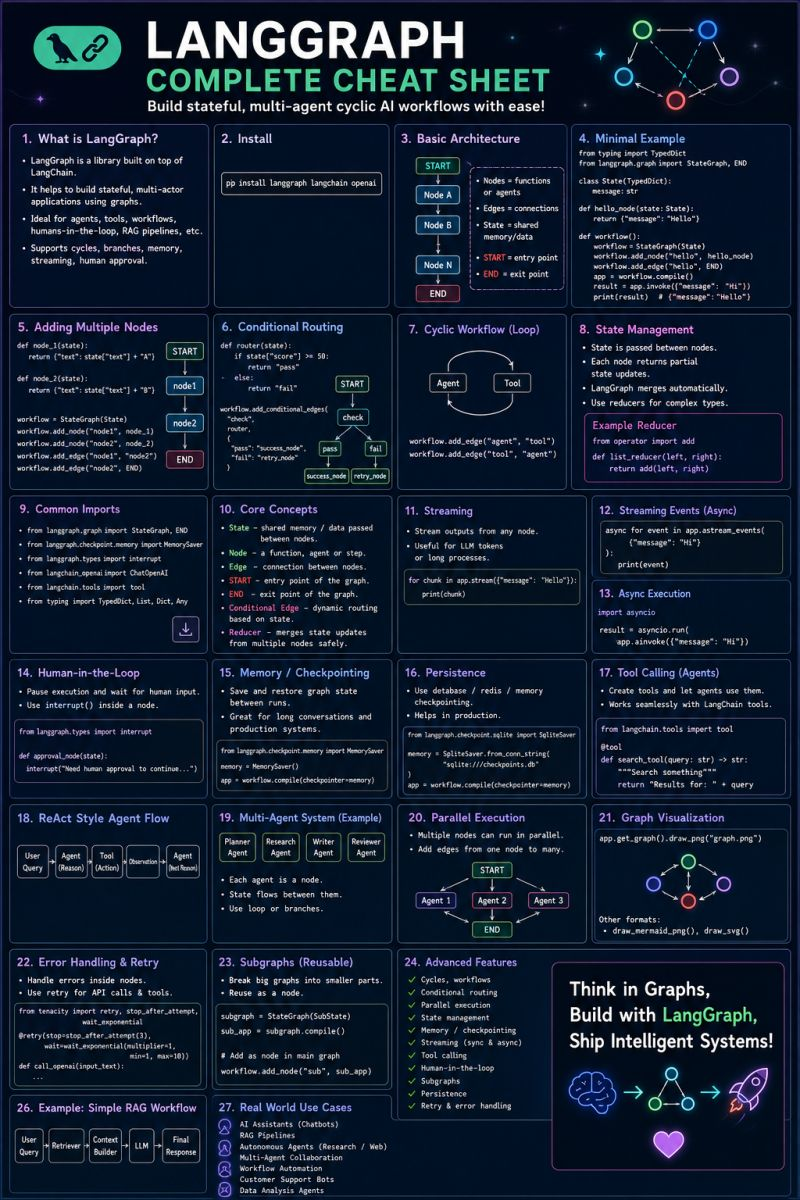